In [8]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path("..") / "ExperimentRunner" / "experiment_results"

supported = {".csv", ".json", ".jsonl", ".parquet"}
files = sorted(
    p for p in results_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in supported
)

def load_experiment_file(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix == ".parquet":
        return pd.read_parquet(path)
    if suffix == ".json":
        data = json.loads(path.read_text(encoding="utf-8"))
        if isinstance(data, list):
            return pd.json_normalize(data)
        if isinstance(data, dict):
            return pd.json_normalize(data)
        return pd.DataFrame({"value": [data]})
    if suffix == ".jsonl":
        return pd.read_json(path, lines=True)
    raise ValueError(f"Unsupported file type: {path}")

csv_path = next((p for p in files if p.suffix.lower() == ".csv"), None)
if csv_path is None:
    raise FileNotFoundError("No .csv experiment file found in 'files'.")

csv_df = load_experiment_file(csv_path).copy()
csv_df = csv_df.sort_values(["Instance", "Evaluations"])
csv_df


,Instance,Algorithm,Params,Seed,BestCost,Evaluations,ElapsedMs,BestFoundAt,Timestamp
18,tai_100_10_0,Random_1_s123,RandomParameters,123,399175,1,0.0654,1,2026-03-16T09:14:07.8920265+00:00
19,tai_100_10_0,Random_10_s123,RandomParameters,123,381715,10,0.4566,9,2026-03-16T09:14:07.8939013+00:00
20,tai_100_10_0,Random_100_s123,RandomParameters,123,373078,100,2.7495,29,2026-03-16T09:14:07.8984901+00:00
21,tai_100_10_0,Random_1000_s123,RandomParameters,123,366190,1000,24.3115,564,2026-03-16T09:14:07.9244034+00:00
22,tai_100_10_0,Random_10000_s123,RandomParameters,123,361571,10000,232.2822,1706,2026-03-16T09:14:08.1603504+00:00
23,tai_100_10_0,Random_100000_s123,RandomParameters,123,358641,100000,1877.4634,56914,2026-03-16T09:14:10.0399739+00:00
24,tai_100_20_0,Random_1_s123,RandomParameters,123,471635,1,0.0727,1,2026-03-16T09:14:10.0418205+00:00
25,tai_100_20_0,Random_10_s123,RandomParameters,123,461315,10,0.5374,6,2026-03-16T09:14:10.0438130+00:00
26,tai_100_20_0,Random_100_s123,RandomParameters,123,452686,100,3.1885,21,2026-03-16T09:14:10.0484888+00:00
27,tai_100_20_0,Random_1000_s123,RandomParameters,123,442531,1000,54.5909,837,2026-03-16T09:14:10.1040345+00:00


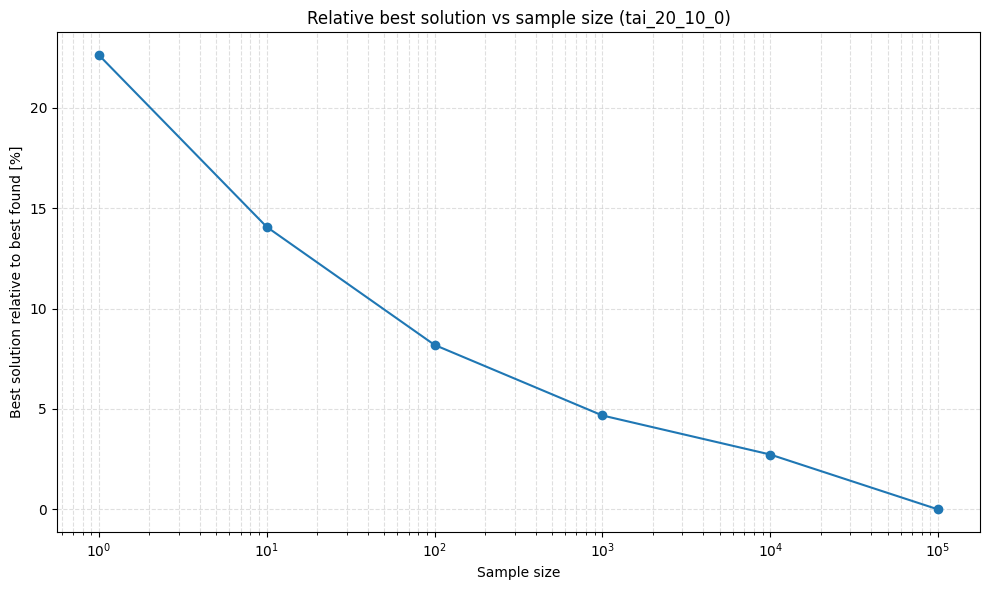

In [9]:

target_instance = "tai_20_10_0"
instance_df = csv_df[csv_df["Instance"] == target_instance].copy()
if instance_df.empty:
    raise ValueError(f"Instance '{target_instance}' not found in {csv_path.name}.")

best_cost = instance_df["BestCost"].min()
instance_df["RelativeBestCostPct"] = ((instance_df["BestCost"] / best_cost) - 1.0) * 100.0

ax = instance_df.plot(
    x="Evaluations",
    y="RelativeBestCostPct",
    marker="o",
    figsize=(10, 6),
    logx=True,
    legend=False,
    color="#1f77b4",
)

ax.set_xlabel("Sample size")
ax.set_ylabel("Best solution relative to best found [%]")
ax.set_title(f"Relative best solution vs sample size ({target_instance})")
ax.grid(True, which="both", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()